# V2_3 · Olsson — Mouse myeloid progenitors (SMART-Seq, including KOs)

**Data**: `olsson_tpm.h5ad` — 640 cells × ~24 k genes (WT 452 + single-KO 141 + double-KO 47) with TPM in `.X`; `fig1b.tsv` provides the feature-gene set from the paper's fig 1b (used as the ordering filter).

**This notebook** (mirrors R tutorial `tutorials2/V2_3_Olsson.ipynb` cell-for-cell):
1. TPM → Census transcript counts → NB CellDataSet (all 640 cells, including KOs)
2. Annotate `Type` (Lsk / Cmp / Gmp / LK / GG1 / IG2 / `Irf8_knockout` / `Gfi1_knockout` / `Gfi1_Irf8_knockout` — **9 categories**)
3. Use the fig 1b feature genes directly as the ordering filter → DDRTree → `order_cells`
4. Visualise where the KO cells fall on the trajectory (incl. `facet_wrap(~Type)`)
5. State × Type distribution heatmap
6. BEAM (`branch_point = 1`) + branch heatmap
7. Single-gene branched pseudotime curves

In [1]:
import re
import numpy as np
import pandas as pd
from pheatmap import pheatmap
from ggplot2_py import facet_wrap
from IPython.display import display

from monocle2py import (
    beam,
    estimate_dispersions,
    estimate_size_factors,
    load_fig1b_ordering_genes,
    load_olsson_tpm,
    new_cell_dataset,
    order_cells,
    plot_cell_trajectory,
    plot_genes_branched_heatmap,
    plot_genes_branched_pseudotime,
    reduce_dimension,
    relative2abs,
    set_ordering_filter,
    tobit,
)

olsson = load_olsson_tpm()
fig1b_table = load_fig1b_ordering_genes()
fig1b_genes = fig1b_table['UID'].dropna().iloc[1:].astype(str).tolist()
print('expr:', olsson.shape, '| fig1b:', len(fig1b_genes), 'genes')

expr: (640, 23955) | fig1b: 532 genes


## 1. Build the CDS — TPM → Census transcript counts

In [2]:
# R: sample_sheet <- data.frame(groups = str_split_fixed(colnames, '\\.+', 3))
# (split on ONE OR MORE dots into exactly 3 parts).
# h5ad round-trip sanitised the original `..` separators in double-KO cell
# names (e.g. `Gfi1..Irf8...B1`) to `--` (→ `Gfi1--Irf8--.B1`); match either
# dots or dashes to recover the R-faithful 3-part split.
sep = re.compile(r'[.\-]+')
def _split3(name):
    parts = sep.split(name, maxsplit=2)
    return (parts + ['', '', ''])[:3]

groups = pd.DataFrame(
    [_split3(n) for n in olsson.obs_names],
    index=olsson.obs_names,
    columns=['groups.1', 'groups.2', 'groups.3'],
)
pheno = pd.concat(
    [olsson.obs.drop(columns=['groups.1', 'groups.2', 'groups.3', 'Type'],
                     errors='ignore'),
     groups],
    axis=1,
)

# TPM CDS — tobit family on the fractional scale, matching R's
# `newCellDataSet(tpm_mat, expressionFamily=negbinomial.size(),
#                 lowerDetectionLimit=1)` as closely as monocle2py supports.
URMM_std = new_cell_dataset(
    olsson.X, pheno_data=pheno.copy(), feature_data=olsson.var.copy(),
    expression_family=tobit(lower=1.0),
    lower_detection_limit=1.0,
)

# Type annotation — R's 3-stage rule:
#   rows  1..452 (WT)          : groups.1
#   rows 453..593 (single-KO)  : groups.1 + '_knockout'
#   rows 594..640 (double-KO)  : groups.1 + '_' + groups.2 + '_knockout'
type_col = pheno['groups.1'].astype(object).copy()
type_col.iloc[452:593] = type_col.iloc[452:593] + '_knockout'
type_col.iloc[593:640] = (
    pheno['groups.1'].iloc[593:640]
    + '_' + pheno['groups.2'].iloc[593:640]
    + '_knockout'
)
URMM_std.obs['Type'] = pd.Categorical(type_col)
print(URMM_std.obs['Type'].value_counts().sort_index().to_string())

Type
Cmp                    94
GG1                    37
Gfi1_Irf8_knockout     47
Gfi1_knockout          79
Gmp                   132
IG2                    33
Irf8_knockout          62
LK                     63
Lsk                    93


In [3]:
# Census: back-compute transcript counts from TPM, then rebuild the CDS
# as a negative-binomial model for downstream differential / BEAM steps.
rpc = relative2abs(URMM_std, method='num_genes')
URMM_abs = new_cell_dataset(
    rpc, pheno_data=URMM_std.obs.copy(),
    feature_data=URMM_std.var.copy(),
    lower_detection_limit=1.0,
)
estimate_size_factors(URMM_abs)
estimate_dispersions(URMM_abs)
print('NB CDS:', URMM_abs.shape)

Removing 1262 outliers
NB CDS: (640, 23955)


## 2. Select ordering genes — use the fig 1b feature-gene set directly

The original tutorial runs tSNE + `clusterCells` + `~Cluster` DEG on the WT subset to pick the top 1000 ordering genes. Here we simplify: the paper's fig 1b already provides a feature-gene set, and we **use it directly as the ordering filter**. Clean and reproducible.

In [4]:
ordering_genes = sorted(set(fig1b_genes) & set(URMM_abs.var_names))
print('fig1b genes used as ordering filter:', len(ordering_genes))
set_ordering_filter(URMM_abs, ordering_genes)

fig1b genes used as ordering filter: 532


AnnData object with n_obs × n_vars = 640 × 23955
    obs: 'groups.1', 'groups.2', 'groups.3', 'Size_Factor', 'Type'
    var: 'gene_short_name', 'use_for_ordering'
    uns: 'monocle2'

## 3. Trajectory inference — DDRTree + `order_cells`

Parameters reuse the ones the original R tutorial tuned for the full 640-cell dataset: `max_components=4, maxIter=100, norm_method='log', scaling=TRUE, lambda=14*N, param.gamma=100`.

In [5]:
reduce_dimension(
    URMM_abs, max_components=4, reduction_method='DDRTree',
    norm_method='log', scaling=True,
    auto_param_selection=True, verbose=False,
    **{'maxIter': 100,
       'lambda': 14 * URMM_abs.n_obs,
       'param.gamma': 100},
)
order_cells(URMM_abs)
print('States:', sorted(URMM_abs.obs['State'].astype(int).unique().tolist()))

States: [1, 2, 3, 4, 5]


## 4. Trajectory visualisation — where do the KO cells fall?

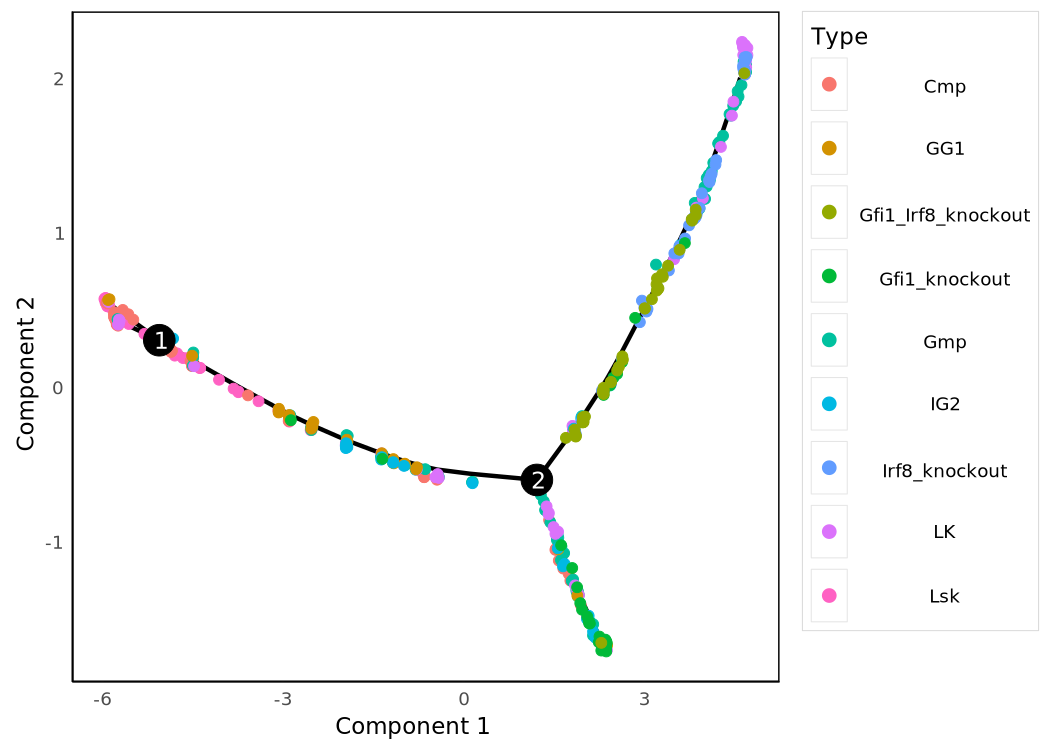

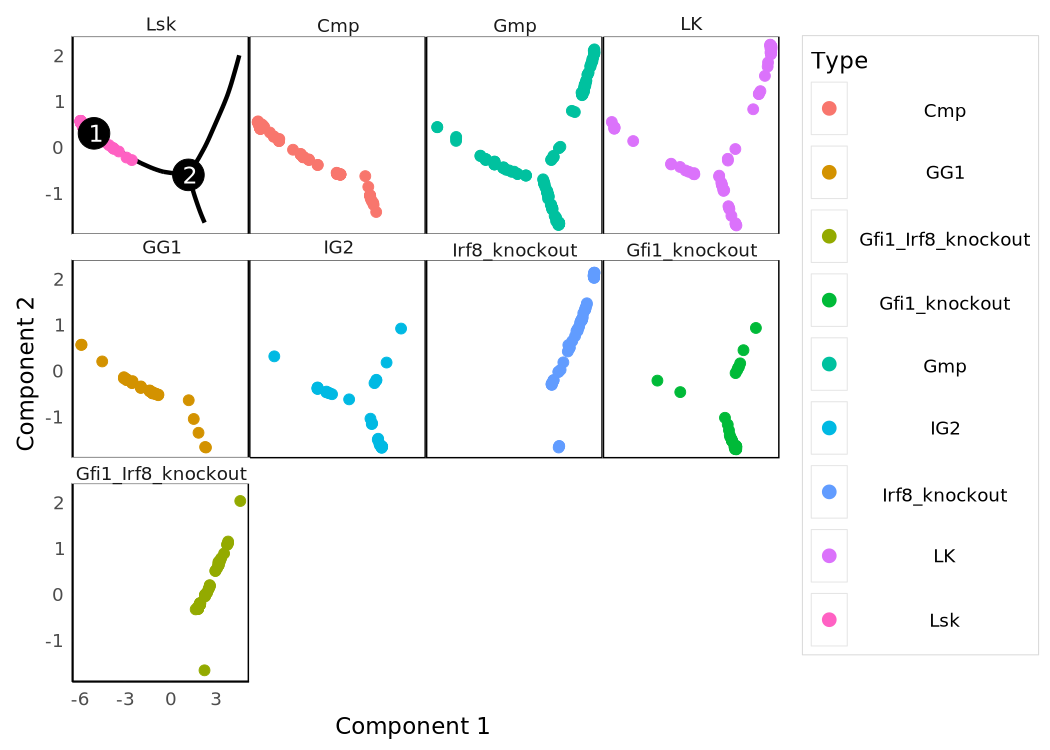

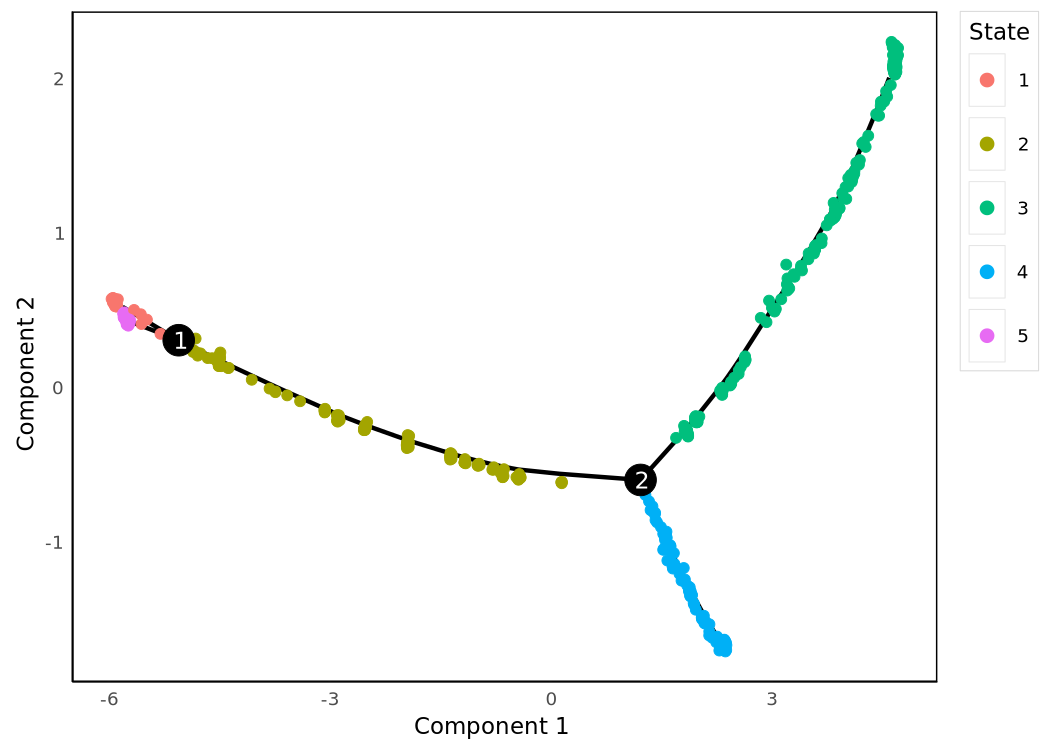

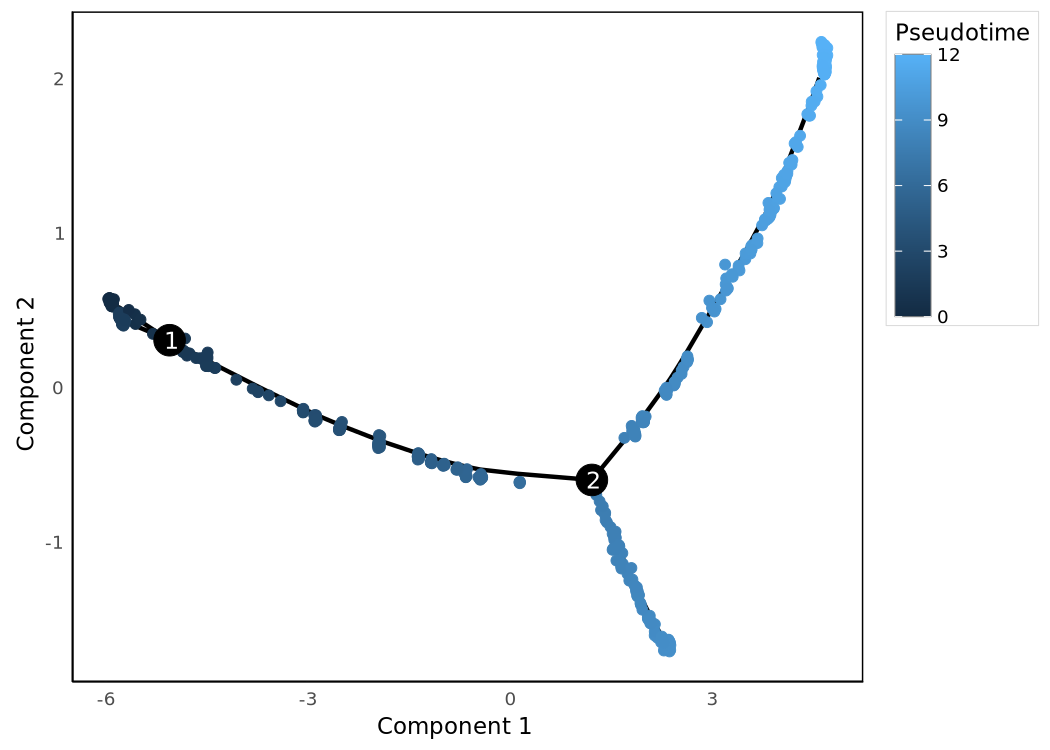

In [6]:
# R cell combines four plots via base-R `print` semantics. Mirror that with
# explicit IPython.display.display() so all four render in this single cell.
display(plot_cell_trajectory(URMM_abs, color_by='Type'))
display(
    plot_cell_trajectory(URMM_abs, color_by='Type')
    + facet_wrap('~Type', ncol=4)
)
display(plot_cell_trajectory(URMM_abs, color_by='State',
                             show_branch_points=True))
display(plot_cell_trajectory(URMM_abs, color_by='Pseudotime',
                             show_branch_points=True))

## 5. State × Type distribution

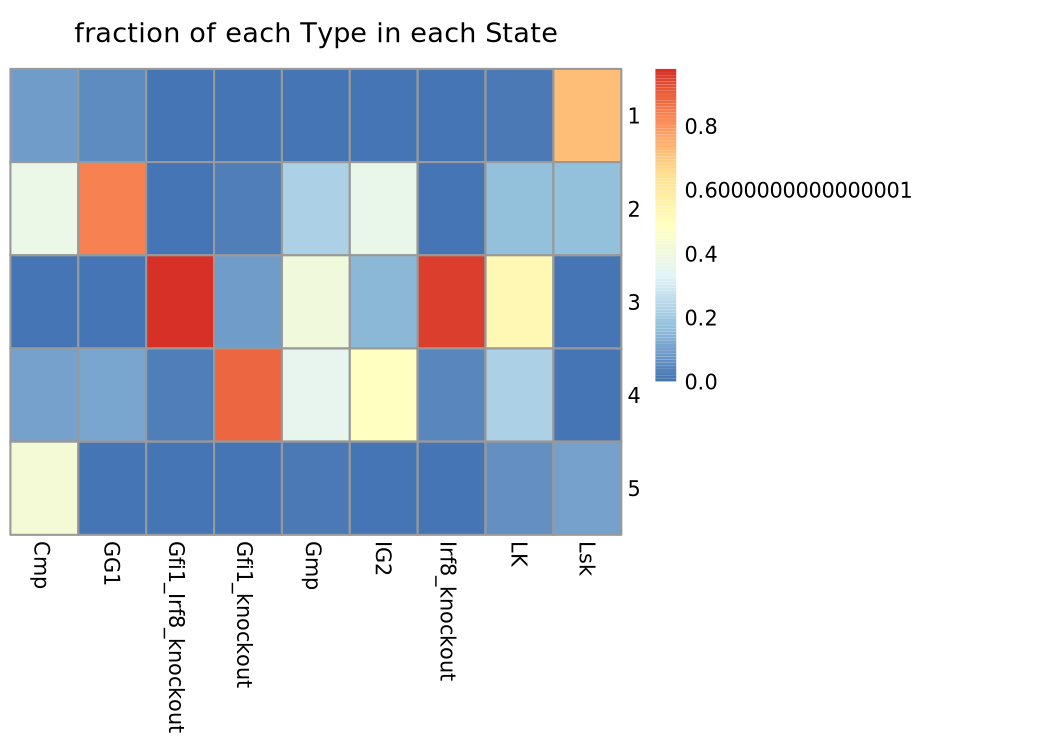

In [7]:
state_type = pd.crosstab(
    URMM_abs.obs['State'].astype(int),
    URMM_abs.obs['Type'],
)
# R: apply(state_type, 2, function(x) x/sum(x)) — column-wise fraction,
# so each Type column sums to 1.
frac = state_type.div(state_type.sum(axis=0), axis=1)
pheatmap(
    frac.to_numpy(),
    cluster_rows=False, cluster_cols=False,
    labels_row=[str(s) for s in frac.index],
    labels_col=list(frac.columns),
    main='fraction of each Type in each State',
)

## 6. BEAM — `branch_point = 1`

In [8]:
beam_res = beam(URMM_abs, branch_point=1, verbose=False).sort_values('qval')
print('qval < 1e-4:', int((beam_res['qval'] < 1e-4).sum()))
beam_res[['gene_short_name', 'pval', 'qval']].head(15)

qval < 1e-4: 301


,gene_short_name,pval,qval
gene_id,,,
S100a8,S100a8,7.156219e-49,9.025423e-45
Ifitm1,Ifitm1,1.334777e-44,8.417106e-41
Cd34,Cd34,6.127421e-38,2.575968e-34
Fcnb,Fcnb,9.593125e-37,3.024712e-33
Ly86,Ly86,3.377453e-36,8.519286e-33
Chil3,Chil3,9.461906e-36,1.988893e-32
Mmp8,Mmp8,1.778939e-32,3.205141e-29
Ctss,Ctss,2.483460e-32,3.915174e-29
Ngp,Ngp,4.100200e-32,5.745747e-29


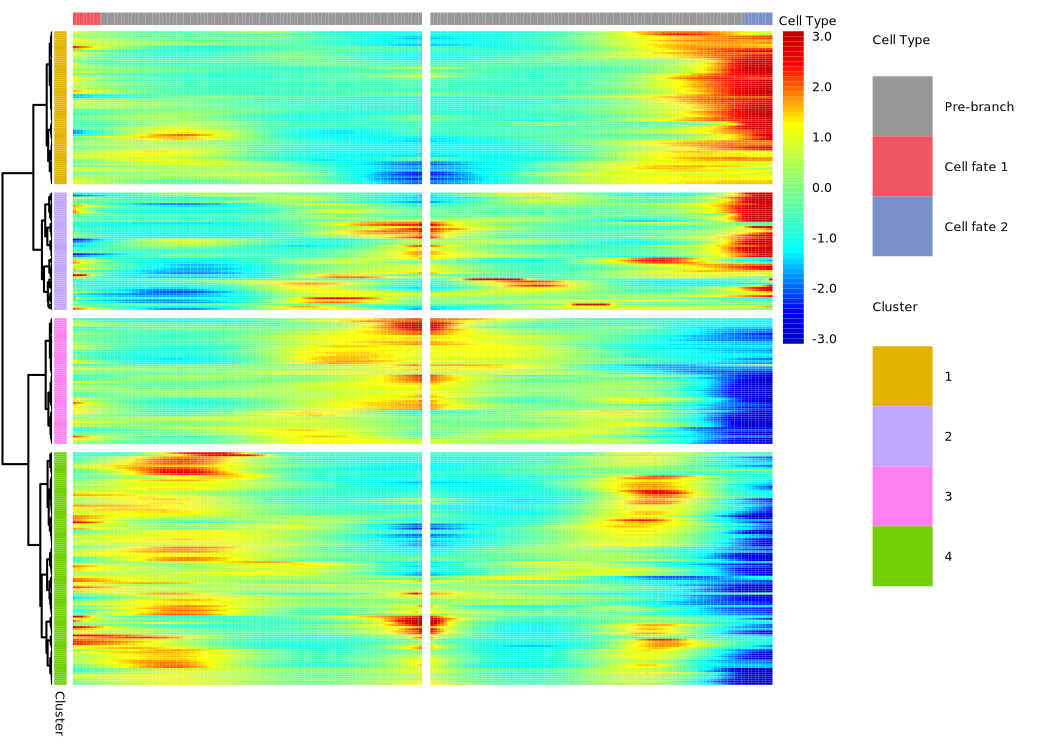

In [9]:
top_genes = beam_res[beam_res['qval'] < 1e-4].index.tolist()
if len(top_genes) >= 5:
    display(plot_genes_branched_heatmap(
        URMM_abs[:, top_genes], branch_point=1,
        num_clusters=4, use_gene_short_name=True,
        show_rownames=False,
    ))
else:
    print('Fewer than 5 BEAM hits at qval<1e-4 — skipping heatmap.')

## 7. Single-gene branched pseudotime curves

Myeloid vs erythroid/megakaryocytic markers: `Car1` / `Car2` (erythroid carbonic anhydrases), `Elane` / `Prtn3` (granulocyte serine proteases).

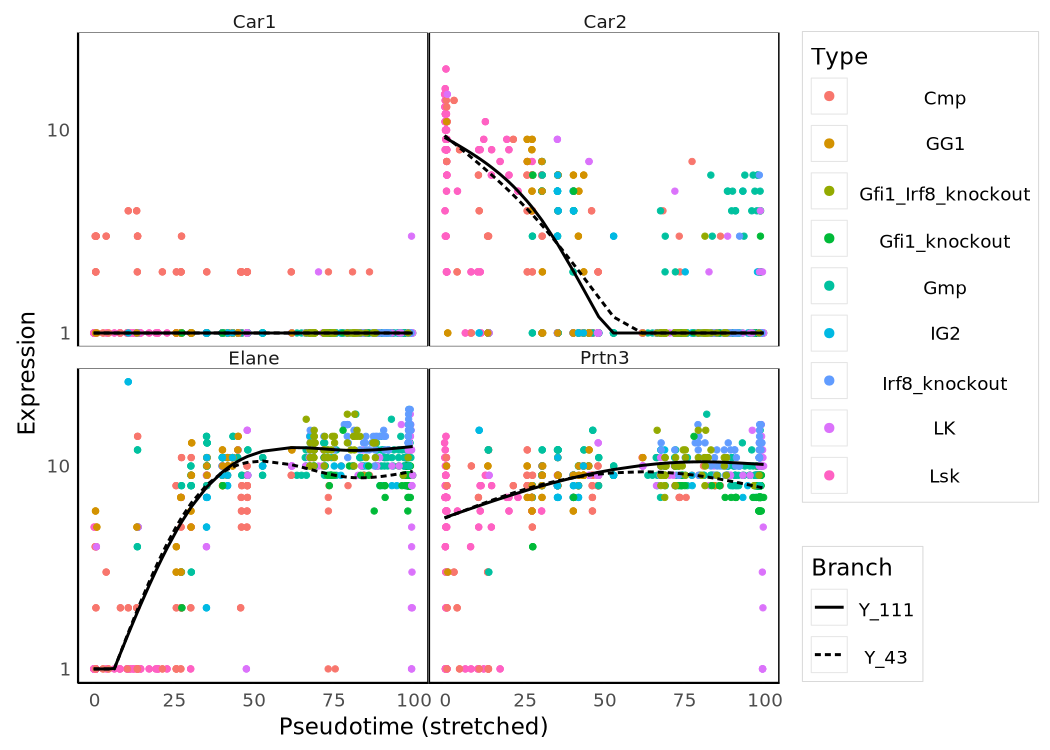

In [10]:
sel_short = ['Car1', 'Car2', 'Elane', 'Prtn3']
sel_genes = URMM_abs.var_names[
    URMM_abs.var['gene_short_name'].isin(sel_short)
].tolist()
if sel_genes:
    display(plot_genes_branched_pseudotime(
        URMM_abs[:, sel_genes], branch_point=1,
        color_by='Type', ncol=2,
    ))
else:
    print('Marker genes not present in the var index.')